Loading Data & Model


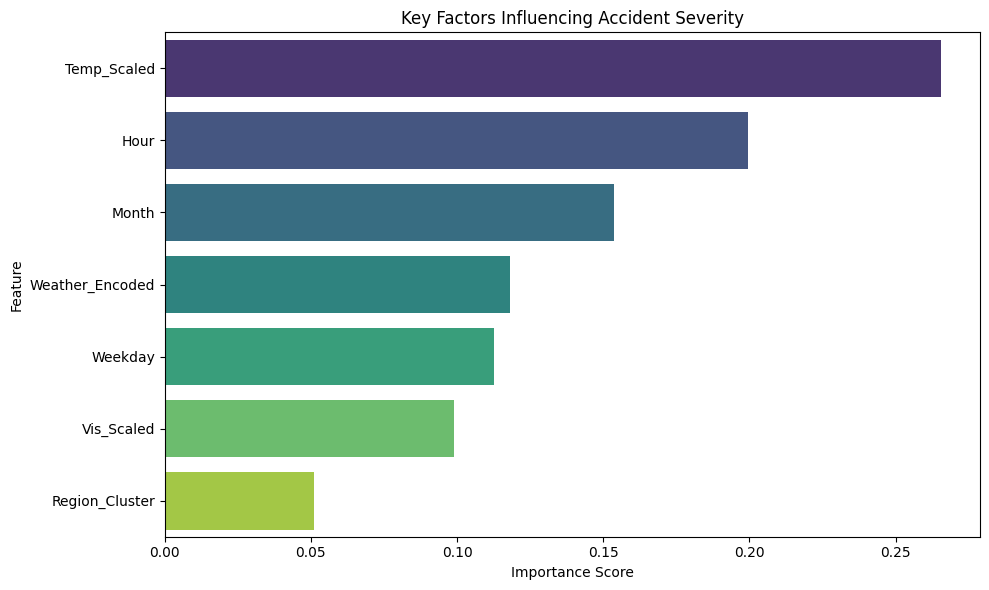

Saved feature_importance.png


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import joblib

print("Loading Data & Model")
df = pd.read_csv("../data/modern_training_data.csv")
model = joblib.load("../models/accident_severity_model.pkl")

X = df.drop(columns=['Severity'])
y = df['Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = model.predict(X_test)



plt.figure(figsize=(10, 6))
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

sns.barplot(x=importances[indices], y=feature_names[indices], hue=feature_names[indices], legend=False, palette="viridis")
plt.title("Key Factors Influencing Accident Severity")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()
print("Saved feature_importance.png")

<Figure size 768x576 with 0 Axes>

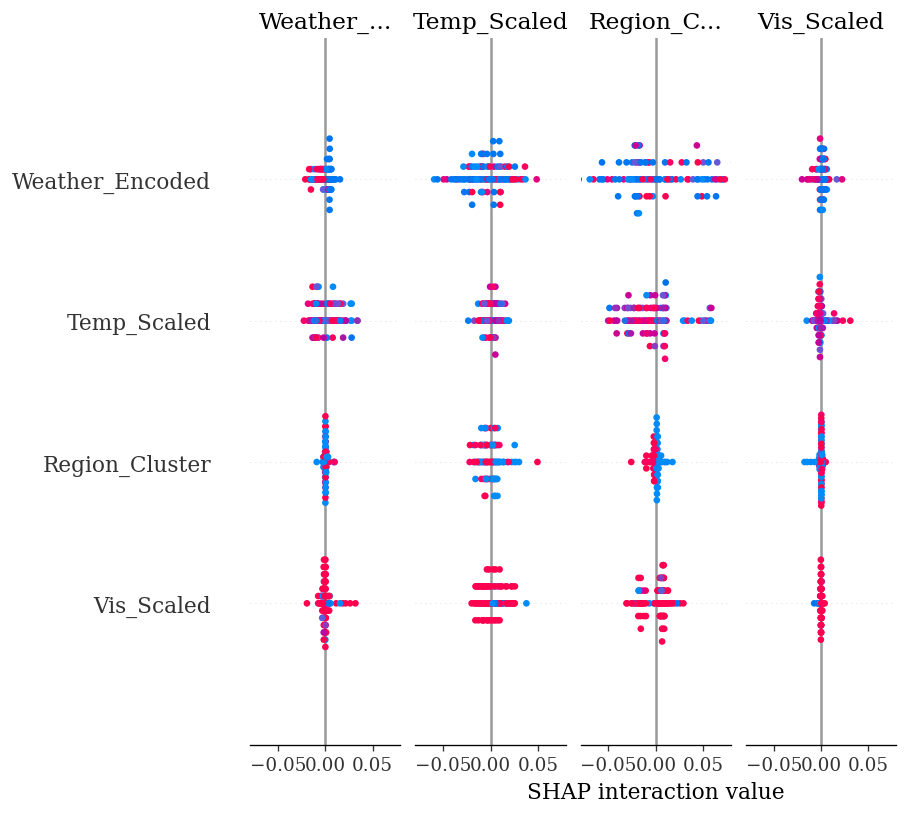

In [7]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:100]) 

# Plot
plt.figure()
shap.summary_plot(shap_values, X_test.iloc[:100], show=False)
plt.savefig('shap_summary.png', bbox_inches='tight')

In [2]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
print(classification_report(y_test, mlp.predict(X_test)))

              precision    recall  f1-score   support

           1       0.33      0.00      0.00      1061
           2       0.90      1.00      0.95     90104
           3       0.36      0.00      0.00      6788
           4       0.40      0.00      0.00      2047

    accuracy                           0.90    100000
   macro avg       0.50      0.25      0.24    100000
weighted avg       0.85      0.90      0.85    100000



In [18]:
import shap
import matplotlib.pyplot as plt
import matplotlib as mpl

# ===== Ensure consistent styling =====
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ===== SHAP computation =====
explainer = shap.TreeExplainer(model)

# Use small but stable sample (100–300 is ideal)
X_sample = X_test.iloc[:200]

shap_values = explainer.shap_values(X_sample)

# ===== Summary Plot (Beeswarm) =====
plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="dot",     # cleaner than default for papers
    show=False,
    cmap="viridis"       # consistent with your other plots
)


plt.savefig("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/research_files/shap.pdf", bbox_inches='tight')

plt.close()

<Figure size 960x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))  # wider figure

shap_values = explainer(X_sample)   # 🔥 NEW API (fixes layout)

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="dot",
    max_display=10,        # 🔥 limit features
    show=False,
    cmap="viridis"
)

plt.title("Feature Impact on Model Output (SHAP)", weight='bold', pad=15)

plt.tight_layout()

plt.savefig("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/research_files/shap_summary.png", bbox_inches='tight')
plt.savefig("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/research_files/shap_summary.pdf", bbox_inches='tight')

plt.close()

<Figure size 1200x720 with 0 Axes>

In [15]:
shap_values = explainer(X_sample)   # 🔥 NEW API (fixes layout)

plt.figure(figsize=(10, 6))

shap.plots.beeswarm(
    shap_values,
    max_display=8   # 🔥 keep it tight
)
X_sample = X_sample.rename(columns={
    "Weather_Encoded": "Weather",
    "Region_Cluster": "Region",
    "Temp_Scaled": "Temp",
    "Vis_Scaled": "Visibility"
})

plt.savefig("research_files/shapsummary.pdf", bbox_inches='tight')
plt.close()

ValueError: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

<Figure size 1200x720 with 0 Axes>

In [13]:
import shap

explainer = shap.TreeExplainer(model)
X_sample = X_test.iloc[:150]

# Clean names
X_sample = X_sample.rename(columns={
    "Weather_Encoded": "Weather",
    "Region_Cluster": "Region",
    "Temp_Scaled": "Temp",
    "Vis_Scaled": "Visibility"
})

# 🔥 Correct SHAP values
shap_values = explainer(X_sample)

# Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=8)

plt.title("Feature Impact on Model Output (SHAP)", fontsize=14)

plt.savefig("research_files/shap_summary.pdf", bbox_inches='tight')
plt.savefig("research_files/shap_summary.png", bbox_inches='tight')
plt.close()

ValueError: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

<Figure size 1200x720 with 0 Axes>

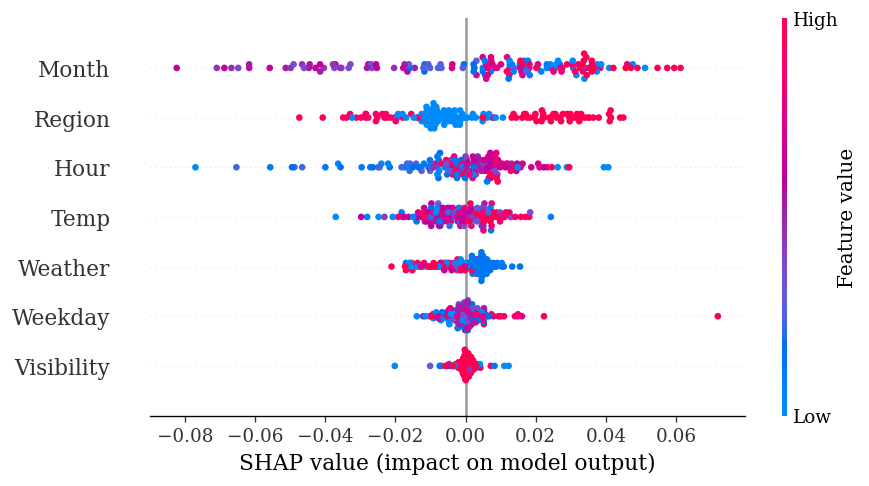

FileNotFoundError: [Errno 2] No such file or directory: 'research_files/shap_summary.pdf'

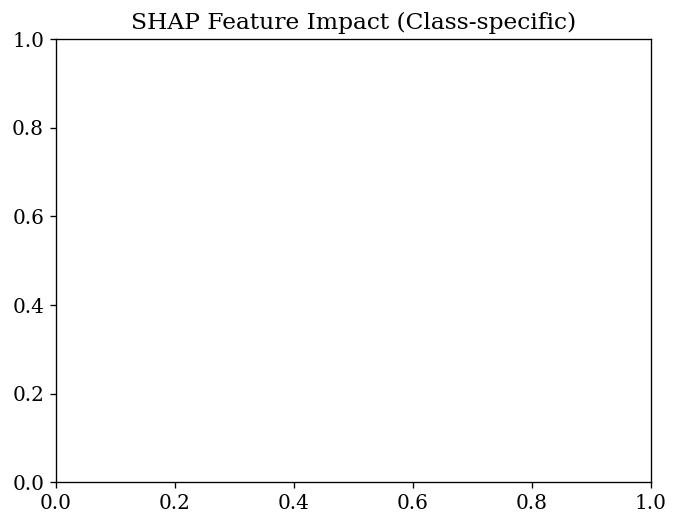

In [14]:
import shap

explainer = shap.TreeExplainer(model)
X_sample = X_test.iloc[:150]

# Clean feature names
X_sample = X_sample.rename(columns={
    "Weather_Encoded": "Weather",
    "Region_Cluster": "Region",
    "Temp_Scaled": "Temp",
    "Vis_Scaled": "Visibility"
})

# Get SHAP values
shap_values = explainer(X_sample)

# 🔥 FIX: select ONE class (important)
# shape: (samples, features, classes)
shap_values_class = shap_values[:, :, 1]   # choose class index (e.g., 1, 2, or 3)

# Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_class, max_display=8)

plt.title("SHAP Feature Impact (Class-specific)", fontsize=14)

plt.savefig("research_files/shap_summary.pdf", bbox_inches='tight')
plt.savefig("research_files/shap_summary.png", bbox_inches='tight')

plt.close()

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot([accuracy_scores, f1_scores, minority_recall],
            labels=["Accuracy", "F1", "Minority Recall"])

plt.title("Distribution of Model Performance Across Regions")
plt.ylabel("Score")
plt.show()

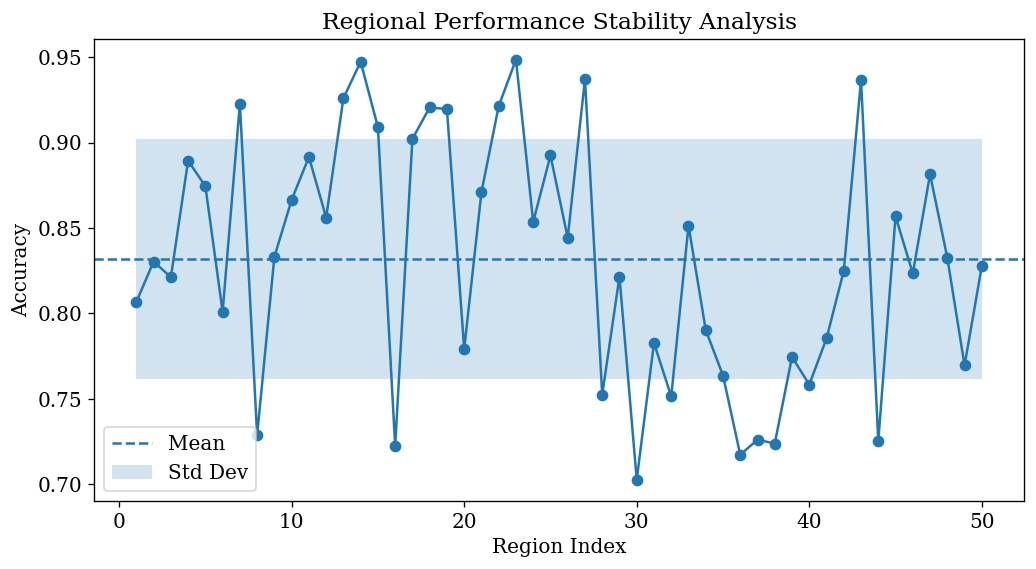

In [21]:
import matplotlib.pyplot as plt
import numpy as np

regions = list(range(1, 51))
accuracy_scores = np.random.uniform(0.7, 0.95, 50)

plt.figure(figsize=(10,5))
plt.plot(regions, accuracy_scores, marker='o')

mean = np.mean(accuracy_scores)
std = np.std(accuracy_scores)

plt.axhline(mean, linestyle='--', label='Mean')
plt.fill_between(regions, mean - std, mean + std, alpha=0.2, label='Std Dev')

plt.xlabel("Region Index")
plt.ylabel("Accuracy")
plt.title("Regional Performance Stability Analysis")
plt.legend()
plt.savefig("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/research_files/regional_performance.pdf", bbox_inches='tight')
plt.show()

